# **I. Import thư viện**

In [6]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# **II. Định nghĩa đường dẫn**

In [7]:
process_path = "../../data/processed"

# **III. Load data**

In [8]:
df_train = pd.read_csv(os.path.join(process_path, "train.csv"))
df_val = pd.read_csv(os.path.join(process_path, "val.csv"))
df_test = pd.read_csv(os.path.join(process_path, "test.csv"))
print("Kích thước:", df_train.shape, df_val.shape, df_test.shape)
# Tách biến mục tiêu (Y) và Đặc trưng (X)
X_train = df_train.drop(columns=['target_delivery_days']).values
y_train = df_train['target_delivery_days'].values
X_val = df_val.drop(columns=['target_delivery_days']).values
y_val = df_val['target_delivery_days'].values
X_test = df_test.drop(columns=['target_delivery_days']).values
y_test = df_test['target_delivery_days'].values

Kích thước: (66444, 16) (9492, 16) (18985, 16)


# **IV. Mô hình**

### **1. Các hàm đánh giá**

In [9]:
def mse_score(y_true, y_pred):
    return np.mean((y_true - y_pred)**2)
def rmse_score(y_true, y_pred):
    return np.sqrt(mse_score(y_true, y_pred))
def mae_score(y_true, y_pred):
    return np.mean(np.abs(y_true - y_pred))
def r2_score(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred)**2)
    ss_tot = np.sum((y_true - np.mean(y_true))**2)
    return 1 - (ss_res / ss_tot)

### PART 1: Linear Regression (From scratch)
#### Section 1: Normal Equations


In [10]:
class NormalEquationRegression:
    def __init__(self):
        self.w = None
        
    def fit(self, X, y):
        # Thêm 1 cột giá trị 1 vào đầu ma trận X để đóng vai trò làm bias (w0)
        Phi = np.hstack([np.ones((X.shape[0], 1)), X])
        
        # Môn Học ML: w = (Phi^T * Phi)^-1 * Phi^T * y
        self.w = np.linalg.pinv(Phi.T @ Phi) @ Phi.T @ y
        
    def predict(self, X):
        Phi = np.hstack([np.ones((X.shape[0], 1)), X])
        return Phi @ self.w

# --- Huấn luyện & Đánh giá mô hình ---
ne_model = NormalEquationRegression()
ne_model.fit(X_train, y_train)

ne_pred_train = ne_model.predict(X_train)
ne_pred_val = ne_model.predict(X_val)

print("Normal Equation - Train RMSE: {:.4f}".format(rmse_score(y_train, ne_pred_train)))
print("Normal Equation - Val RMSE:   {:.4f}".format(rmse_score(y_val, ne_pred_val)))
print("Normal Equation - Val R2:     {:.4f}".format(r2_score(y_val, ne_pred_val)))


Normal Equation - Train RMSE: 7.0968
Normal Equation - Val RMSE:   7.3016
Normal Equation - Val R2:     0.2362


#### Section 2: Mini-batch Gradient Descent & LR Schedule


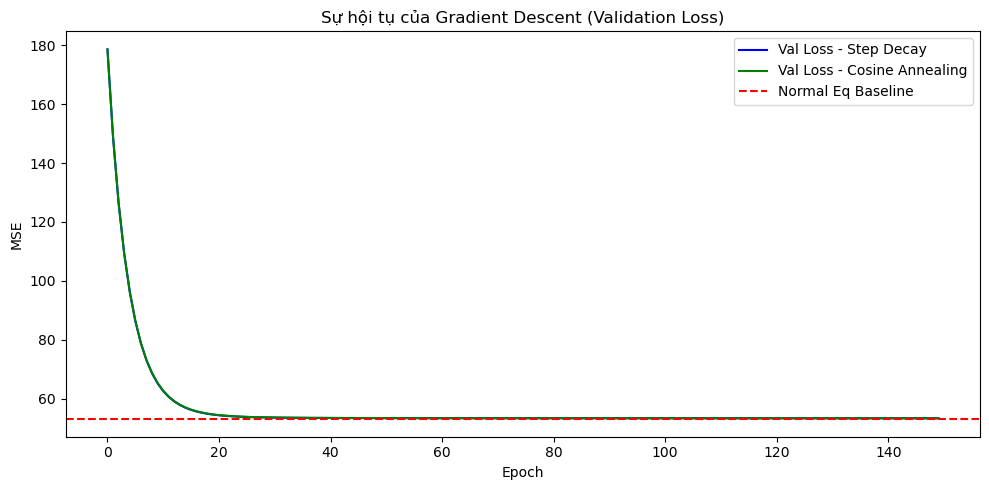

In [15]:
# Các lịch trình cập nhật Learning Rate
def step_decay(epoch, lr0=0.01, drop=0.5, epochs_drop=50):
    return lr0 * (drop ** (epoch // epochs_drop))

def cosine_annealing(epoch, T_max, lr_min=1e-5, lr_max=0.01):
    return lr_min + 0.5 * (lr_max - lr_min) * (1 + np.cos(np.pi * epoch / T_max))

class MiniBatchGDRegression:
    def __init__(self, lr_schedule='step', lr0=0.01, batch_size=256, epochs=200):
        self.lr_schedule = lr_schedule
        self.lr0 = lr0
        self.batch_size = batch_size
        self.epochs = epochs
        self.w = None
        self.loss_history = {'train': [], 'val': []}
        
    def fit(self, X_train, y_train, X_val, y_val):
        Phi_train = np.hstack([np.ones((X_train.shape[0], 1)), X_train])
        Phi_val = np.hstack([np.ones((X_val.shape[0], 1)), X_val])
        
        n_samples, n_features = Phi_train.shape
        self.w = np.zeros(n_features) # Khởi tạo trọng số W bằng 0
        
        for epoch in range(self.epochs):
            # Tính learning rate hiện tại
            if self.lr_schedule == 'step':
                lr = step_decay(epoch, lr0=self.lr0, drop=0.5, epochs_drop=50)
            elif self.lr_schedule == 'cosine':
                lr = cosine_annealing(epoch, T_max=self.epochs, lr_max=self.lr0)
            else:
                lr = self.lr0
                
            # Trộn data (Shuffling)
            indices = np.random.permutation(n_samples)
            
            for start_idx in range(0, n_samples, self.batch_size):
                batch_idx = indices[start_idx:start_idx + self.batch_size]
                X_b = Phi_train[batch_idx]
                y_b = y_train[batch_idx]
                
                # Gradient = X^T * (X*w - y) / batch_size
                predictions = X_b @ self.w
                errors = predictions - y_b
                gradient = (X_b.T @ errors) / self.batch_size
                
                # Cập nhật trọng số
                self.w -= lr * gradient
                
            # Ghi lại giá trị Loss (MSE) mỗi epoch
            self.loss_history['train'].append(mse_score(y_train, Phi_train @ self.w))
            self.loss_history['val'].append(mse_score(y_val, Phi_val @ self.w))
            
    def predict(self, X):
        Phi = np.hstack([np.ones((X.shape[0], 1)), X])
        return Phi @ self.w

# --- Chạy mô hình và so sánh ---
# Giảm thiểu lại epochs để quá trình huấn luyện nhanh qua (VD: 100)
epochs_run = 150
lr_init = 0.0005 # Bạn có thể đổi thử để thấy sự khác biệt

# 1. Thử với Step decay
gd_step = MiniBatchGDRegression(lr_schedule='step', lr0=lr_init, epochs=epochs_run)
gd_step.fit(X_train, y_train, X_val, y_val)

# 2. Thử với Cosine Annealing
gd_cos = MiniBatchGDRegression(lr_schedule='cosine', lr0=lr_init, epochs=epochs_run)
gd_cos.fit(X_train, y_train, X_val, y_val)

# 3. Vẽ Loss Curve so sánh sự hội tụ
plt.figure(figsize=(10, 5))
plt.plot(gd_step.loss_history['val'], label='Val Loss - Step Decay', color='blue')
plt.plot(gd_cos.loss_history['val'], label='Val Loss - Cosine Annealing', color='green')
# Đường Loss bằng Normal Equation để làm mốc Benchmark
plt.axhline(mse_score(y_val, ne_pred_val), color='red', linestyle='--', label='Normal Eq Baseline')

plt.title('Sự hội tụ của Gradient Descent (Validation Loss)')
plt.xlabel('Epoch')
plt.ylabel('MSE')
plt.legend()
plt.tight_layout()
plt.show()
